In [32]:
import numpy as np

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (28709, 48, 48, 1)
Test shape: (7178, 48, 48, 1)


In [33]:
from sklearn.model_selection import train_test_split

# Suppose you already loaded X_train, y_train, X_test, y_test

# Split training data into train + validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,   # 20% of training data becomes validation
    random_state=42, # for reproducibility
    stratify=y_train # keeps class distribution balanced
)

print("Train split shape:", X_train_split.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

class_id_angry = 0
class_id_disgust = 1
class_id_fear = 2
class_id_happy = 3
class_id_sad = 4
class_id_surprise = 5
class_id_neutral = 6

Train split shape: (22967, 48, 48, 1)
Validation shape: (5742, 48, 48, 1)
Test shape: (7178, 48, 48, 1)


In [34]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

#datagen.fit(X_train_split)

# Example for Disgust class
disgust_idx = np.where(y_train_split == class_id_disgust)[0]
X_disgust = X_train[disgust_idx]
y_disgust = y_train[disgust_idx]

augmented_disgust = []
augmented_labels = []
for X_batch, y_batch in datagen.flow(X_disgust, y_disgust, batch_size=32):
    augmented_disgust.append(X_batch)
    augmented_labels.append(y_batch)
    if len(augmented_disgust) > len(X_disgust):  # stop when balanced
        break

# Merge back into training set
X_train_balanced = np.concatenate([X_train, np.vstack(augmented_disgust)])
y_train_balanced = np.concatenate([y_train, np.vstack(augmented_labels)])

In [35]:
# will it update
# batch size

In [36]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Keep data in (num_samples, 48, 48, 1)
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# AE1: Input (48,48,1) → Flatten → 512 → 2304
input_img = Input(shape=(48, 48, 1))
x = Flatten()(input_img)
encoded1 = Dense(512, activation='relu', name='ae1_encoded')(x)
decoded1 = Dense(48*48, activation='sigmoid', name='ae1_decoded')(encoded1)

autoencoder1 = Model(input_img, decoded1)
autoencoder1.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder1.fit(X_train, X_train.reshape((X_train.shape[0], 48*48)),
                 epochs=50, batch_size=32,
                 validation_data=(X_val, X_val.reshape((X_val.shape[0], 48*48))))

encoder1 = Model(input_img, encoded1)
X_train_encoded1 = encoder1.predict(X_train)
X_val_encoded1   = encoder1.predict(X_val)

# AE2: 512 → 256 → 512
input_encoded1 = Input(shape=(512,))
encoded2 = Dense(256, activation='relu', name='ae2_encoded')(input_encoded1)
decoded2 = Dense(512, activation='sigmoid', name='ae2_decoded')(encoded2)

autoencoder2 = Model(input_encoded1, decoded2)
autoencoder2.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder2.fit(X_train_encoded1, X_train_encoded1,
                 epochs=50, batch_size=32,
                 validation_data=(X_val_encoded1, X_val_encoded1))

encoder2 = Model(input_encoded1, encoded2)
X_train_encoded2 = encoder2.predict(X_train_encoded1)
X_val_encoded2   = encoder2.predict(X_val_encoded1)

# AE3: 256 → 128 → 256
input_encoded2 = Input(shape=(256,))
encoded3 = Dense(128, activation='relu', name='ae3_encoded')(input_encoded2)
decoded3 = Dense(256, activation='sigmoid', name='ae3_decoded')(encoded3)

autoencoder3 = Model(input_encoded2, decoded3)
autoencoder3.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder3.fit(X_train_encoded2, X_train_encoded2,
                 epochs=50, batch_size=32,
                 validation_data=(X_val_encoded2, X_val_encoded2))

encoder3 = Model(input_encoded2, encoded3)
X_train_encoded3 = encoder3.predict(X_train_encoded2)
X_val_encoded3   = encoder3.predict(X_val_encoded2)

# AE4: 128 → 64 → 128
input_encoded3 = Input(shape=(128,))
encoded4 = Dense(64, activation='relu', name='ae4_encoded')(input_encoded3)
decoded4 = Dense(128, activation='sigmoid', name='ae4_decoded')(encoded4)

autoencoder4 = Model(input_encoded3, decoded4)
autoencoder4.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder4.fit(X_train_encoded3, X_train_encoded3,
                 epochs=50, batch_size=32,
                 validation_data=(X_val_encoded3, X_val_encoded3))

encoder4 = Model(input_encoded3, encoded4)
X_train_encoded4 = encoder4.predict(X_train_encoded3)
X_val_encoded4   = encoder4.predict(X_val_encoded3)


Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.0086 - val_loss: 2.8606e-05
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 1.3761e-05 - val_loss: 9.3702e-06
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 6.9581e-06 - val_loss: 6.4757e-06
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 5.6010e-06 - val_loss: 5.5866e-06
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 5.1300e-06 - val_loss: 5.1944e-06
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 4.9124e-06 - val_loss: 4.9841e-06
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 4.8011e-06 - val_loss: 4.8749e-06
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 4.7387e-06 - val_loss: 4.8024e-06
Epoch 9/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 4.6979e-06 - val_loss: 4.7542e-06
Epoch 10/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 4.6692e-06 - val_loss: 4.7198e-06
Epoch 11/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 15

In [37]:
# Training model : Softmax Classifier 

In [38]:
# Built classifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Build deeper classifier
# Input as image shape
input_img = Input(shape=(48, 48, 1))

# Flatten inside the classifier
x = Flatten()(input_img)

h1 = Dense(512, activation='relu', name='dense_61')(x)
h2 = Dense(256, activation='relu', name='dense_62')(h1)
h3 = Dense(128, activation='relu', name='dense_63')(h2)
h4 = Dense(64, activation='relu', name='dense_64')(h3)
output = Dense(7, activation='softmax', name='dense_65')(h4)

stacked_model = Model(input_img, output)

In [39]:
#Transfer pretrained weights
# Transfer AE1 → stacked dense_61
stacked_model.get_layer('dense_61').set_weights(
    encoder1.get_layer('ae1_encoded').get_weights()
)
stacked_model.get_layer('dense_62').set_weights(
    encoder2.get_layer('ae2_encoded').get_weights()
)
stacked_model.get_layer('dense_63').set_weights(
    encoder3.get_layer('ae3_encoded').get_weights()
)
stacked_model.get_layer('dense_64').set_weights(
    encoder4.get_layer('ae4_encoded').get_weights()
)

stacked_model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

In [47]:
# Step 3 : Train classifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

#Compute class weights
#y_train_classes = np.argmax(y_train, axis=1)
#class_weights = compute_class_weight(
#    class_weight='balanced',
#    classes=np.unique(y_train_classes),
#    y=y_train_classes
#)
#class_weights_dict = dict(enumerate(class_weights))

# scale weights down a bit to avoid over-correction
#class_weights_dict = {cls: w * 0.7 for cls, w in class_weights_dict.items()}
#print("Class Weights:", class_weights_dict)

# Augmentation
#datagen = ImageDataGenerator(
#    rotation_range=10,
#    width_shift_range=0.1,
#    height_shift_range=0.1,
#    zoom_range=0.1,
#    horizontal_flip=True
#)

# Fit generator on training data
#datagen.fit(X_train.reshape(-1, 48, 48, 1))  # reshape back to image form for augmentation

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

# Train classifier
start = time.time()
history = stacked_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    # class_weight=class_weights_dict,  # uncomment if using class weights
    callbacks=[early_stop, reduce_lr, checkpoint]
)
end = time.time()

print("Total Training Time (sec):", end - start)

# Save the final model with best weights already restored
best_test_acc = 0.0

loss, acc = stacked_model.evaluate(X_test, y_test, verbose=1)
print("Test Accuracy:", acc)

if acc > best_test_acc:
    best_test_acc = acc
    stacked_model.save("ReRun_DenseAutoencoder_SoftmaxClassifier.keras")
    print("New best test model saved with accuracy:", acc)

Epoch 1/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7011 - loss: 0.8135 - val_accuracy: 0.7069 - val_loss: 0.7866 - learning_rate: 0.0010
Epoch 2/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7008 - loss: 0.8082 - val_accuracy: 0.7133 - val_loss: 0.7690 - learning_rate: 0.0010
Epoch 3/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7028 - loss: 0.8029 - val_accuracy: 0.7257 - val_loss: 0.7626 - learning_rate: 0.0010
Epoch 4/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7015 - loss: 0.7980 - val_accuracy: 0.6998 - val_loss: 0.7958 - learning_rate: 0.0010
Epoch 5/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7070 - loss: 0.7932 - val_accuracy: 0.7273 - val_loss: 0.7378 - learning_rate: 0.0010
Epoch 6/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7102 - loss: 0.7799 - val_accuracy: 0.7039 - val_loss: 0.7849 - learning_rate: 0.0010
Epoch 7/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7

In [48]:
# Step 4 : Evaluate

final_train_loss = history.history['loss'][-1]
final_train_acc  = history.history['accuracy'][-1]
final_val_loss   = history.history['val_loss'][-1]
final_val_acc    = history.history['val_accuracy'][-1]

# Evaluate classifier on test set
test_loss, test_acc = stacked_model.evaluate(X_test, y_test, verbose=0)

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Final Training Loss: 0.1120
Final Training Accuracy: 0.9689
Final Validation Loss: 0.1047
Final Validation Accuracy: 0.9720
Test Loss: 5.3748
Test Accuracy: 0.4264


In [49]:
# Precise Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import time

# Predict on test set
y_pred_probs = stacked_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# FER2013 has 7 emotion classes
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Accuracy, Precision, Recall, F1
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_labels))

# IoU (Intersection over Union) for each class
ious = []
for cls in range(len(emotion_labels)):
    tp = np.sum((y_true == cls) & (y_pred == cls))
    fp = np.sum((y_true != cls) & (y_pred == cls))
    fn = np.sum((y_true == cls) & (y_pred != cls))
    iou = tp / (tp + fp + fn + 1e-7)
    ious.append(iou)
# Print IoU per class
for label, iou in zip(emotion_labels, ious):
    print(f"{label}: {iou:.4f}")

# mAP (mean Average Precision) approximation
# Here we treat each class as binary classification
aps = []
for cls in range(len(emotion_labels)):
    cls_true = (y_true == cls).astype(int)
    cls_pred = y_pred_probs[:, cls]
    # simple average precision calculation
    sorted_idx = np.argsort(-cls_pred)
    tp_cumsum = np.cumsum(cls_true[sorted_idx])
    precision = tp_cumsum / (np.arange(len(cls_true)) + 1)
    aps.append(np.mean(precision))
print("mAP:", np.mean(aps))

# Inference Time
start_infer = time.time()
_ = stacked_model.predict(X_test[:100])  # predict 100 samples
end_infer = time.time()

avg_infer_time = (end_infer - start_infer) / 100
print("Average inference time per image:", avg_infer_time, "seconds")

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

       Angry       0.33      0.33      0.33       991
     Disgust       0.37      0.34      0.36       109
        Fear       0.32      0.35      0.33      1024
       Happy       0.59      0.54      0.57      1798
         Sad       0.33      0.33      0.33      1216
    Surprise       0.58      0.61      0.59       800
     Neutral       0.39      0.38      0.38      1240

    accuracy                           0.43      7178
   macro avg       0.41      0.41      0.41      7178
weighted avg       0.43      0.43      0.43      7178

Angry: 0.1977
Disgust: 0.2164
Fear: 0.1984
Happy: 0.3958
Sad: 0.1966
Surprise: 0.4225
Neutral: 0.2370
mAP: 0.2566984604837537
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Average inference time per image: 0.0011383390426635742 seconds


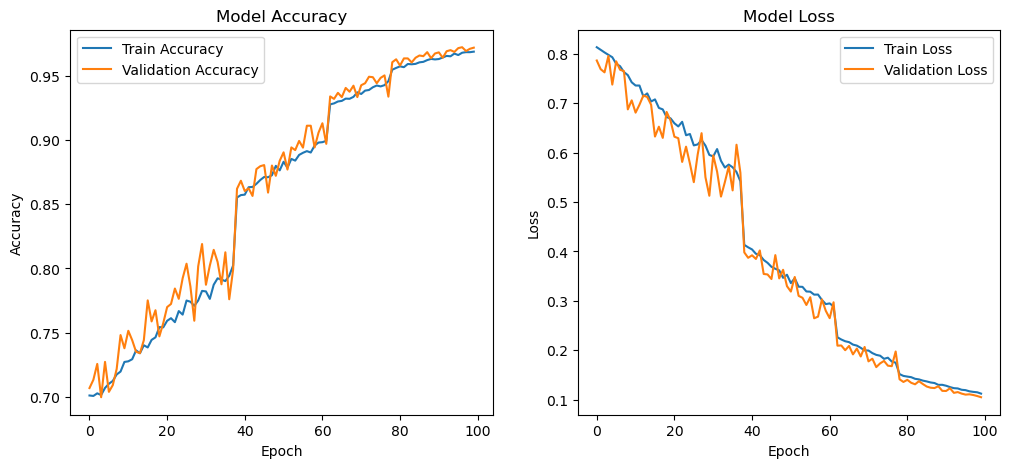

In [50]:
# Visualization
import matplotlib.pyplot as plt


# Plot accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


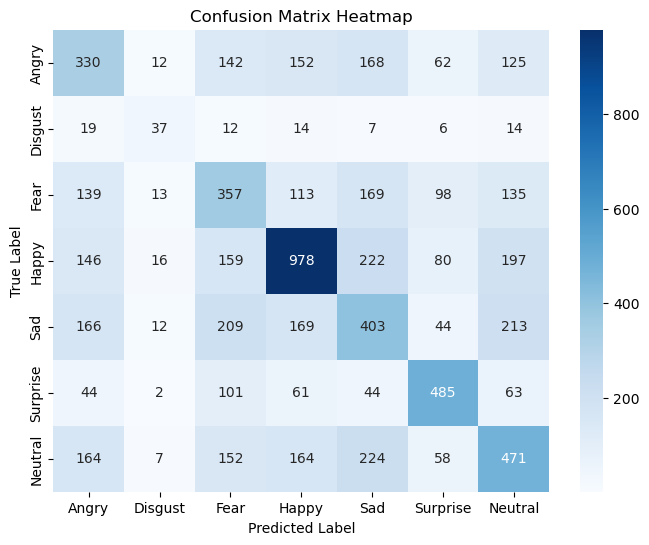

In [51]:
# Emotion confusion heatmap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [52]:
print("\n=== Final Evaluation Summary ===")
print(f"Training Loss: {final_train_loss:.4f}")
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Total Training Time (sec): {total_training_time:.2f}")
print(f"Average Inference Time per Image: {avg_infer_time:.6f} sec")
print("================================")


=== Final Evaluation Summary ===
Training Loss: 0.1120
Training Accuracy: 0.9689
Validation Loss: 0.1047
Validation Accuracy: 0.9720
Test Loss: 5.3748
Test Accuracy: 0.4264
Total Training Time (sec): 938.21
Average Inference Time per Image: 0.001138 sec


In [53]:
#import keras
#keras.saving.save_model(stacked_model, "ReRun_DenseAutoencoder_SoftmaxClassifier.keras")